Per-galaxy Spearman rho vs total metallicity (all galaxies)
All galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Reading total metallicity from: ./sfr_logs/{gal}.log (O3N2-M13)

Processing IC3392 ...
  Total metallicity (log): 8.564747
  Map indicator used for offsets: O3N2-M13
  Spearman rho (3σ + trend): r=0.234 (p=1.02e-177), n_used=14295, n_valid=14906

Processing NGC4064 ...
  Total metallicity (log): 8.594243
  Map indicator used for offsets: O3N2-M13
  Spearman rho (3σ + trend): r=0.780 (p=0), n_used=6459, n_valid=7077

Processing NGC4192 ...
  Total metallicity (log): 8.549517
  Map indicator used for offsets: O3N2-M13
  Spearman rho (3σ + trend): r=-0.010 (p=8.83e-05), n_used=144513, n_valid=146165

Processing NGC4293 ...
  Total metallicity (log): 8.529932
  Map indicator used for offsets: O3N2-M13
  Spearman rho (3σ + trend): r=-0.272 (p=7.03e-97), n_used=5687, n_valid=5715

Processing NGC42

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_17279/269636989.py:263: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


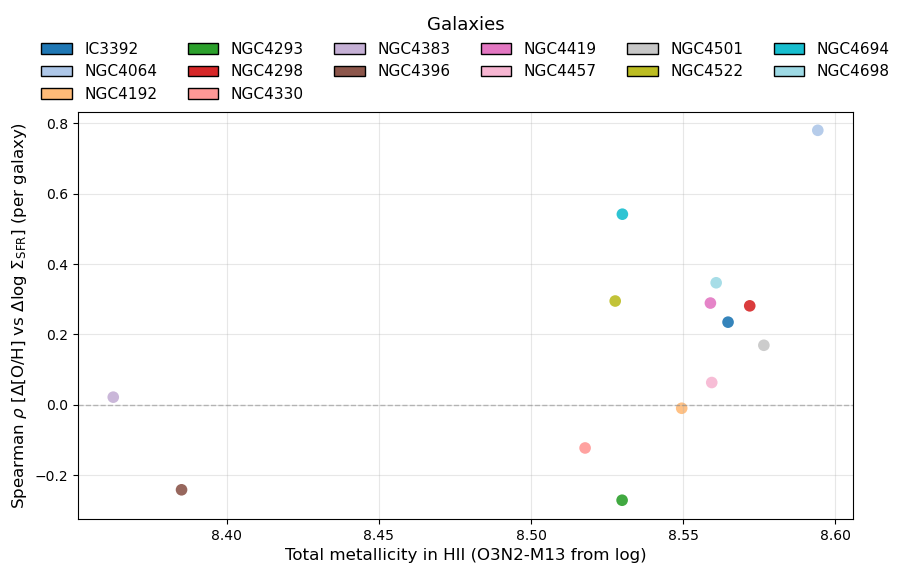

In [2]:
# ------------------------------------------------------------------
# Per-galaxy Spearman: Δ[O/H] vs Δlog Σ_SFR (no Σ_* bins)
# X-axis: total metallicity from logs in ./sfr_logs/{gal}.log
# ------------------------------------------------------------------
from pathlib import Path
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr
from matplotlib.patches import Patch

# ------------------------------------------------------------------
# Helper: read the required maps
# ------------------------------------------------------------------
def load_maps(gal):
    spatial_path = f"{gal}_SPATIAL_BINNING_maps_extended.fits"
    gas_path = f"{gal}_gas_BIN_maps_extended.fits"

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f"Required FITS files for {gal} not found.")

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas["LOGSFR_SURFACE_DENSITY_HII"].data
        # Prefer M13 to match the total-metallicity logs (O3N2-M13)
        if "O_H_O3N2_M13_HII" in h_gas:
            oh_map = h_gas["O_H_O3N2_M13_HII"].data
            indicator_name = "O3N2-M13"
        elif "O_H_O3N2_M14_HII" in h_gas:
            print(f"Warning: O3N2-M13 not available for {gal}; using O3N2-M14 instead.")
            oh_map = h_gas["O_H_O3N2_M14_HII"].data
            indicator_name = "O3N2-M14"
        else:
            available = [hdu.name for hdu in h_gas]
            raise KeyError(
                f"No O3N2 metallicity extension (M13/M14) found for {gal}. Available: {available}"
            )
    return sigM, sigSFR, oh_map, indicator_name

# ------------------------------------------------------------------
# Helper: read total metallicity from logs
# Example line:
# [O/H] O3N2-M13 HII: Total metallicity in HII region:  8.564746505568046
# ------------------------------------------------------------------
def read_total_metallicity_from_log(gal, log_dir="sfr_logs"):
    log_path = Path(log_dir) / f"{gal}.log"
    if not log_path.exists():
        raise FileNotFoundError(f"Log file not found: {log_path}")

    text = log_path.read_text(errors="replace")
    pattern = (
        r"\[O/H\]\s*O3N2-M13\s*HII:\s*Total metallicity in HII region:\s*"
        r"([0-9]+(?:\.[0-9]+)?)"
    )
    match = re.search(pattern, text)
    if not match:
        raise ValueError(
            f"Could not find total metallicity line in {log_path} matching O3N2-M13 total metallicity."
        )
    return float(match.group(1))

# ------------------------------------------------------------------
# Helper: calculate binned statistics with unique-count requirement
# (Used only as a 'trend exists' check; optional but kept for consistency)
# ------------------------------------------------------------------
def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
    """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)

    finite = np.isfinite(x_data) & np.isfinite(y_data)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
    if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    if bin_edges.size < 2:
        return np.array([]), np.array([]), np.array([]), np.array([])

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    medians = []
    stds = []
    counts = []
    valid_centers = []

    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
        if np.sum(in_bin) == 0:
            continue

        y_in_bin = y_data[in_bin]
        if len(np.unique(y_in_bin)) >= min_unique:
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])

    return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts))

# ------------------------------------------------------------------
# Galaxy list and color map
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.split("_")[0] for f in bins]

# Build galaxy -> color mapping over ALL galaxies
galaxy_colors_all = plt.cm.tab20(np.linspace(0, 1, max(len(galaxies_all), 1)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

# Use all galaxies (do not exclude NGC4383)
galaxies = list(galaxies_all)

print("=" * 80)
print("Per-galaxy Spearman rho vs total metallicity (all galaxies)")
print("All galaxies:", ", ".join(galaxies_all) if galaxies_all else "<none found>")
print("Reading total metallicity from: ./sfr_logs/{gal}.log (O3N2-M13)")
print("=" * 80)

# ------------------------------------------------------------------
# Loop over galaxies: compute one rho per galaxy + read total metallicity
# ------------------------------------------------------------------
galaxy_names = []
galaxy_total_metallicity = []
galaxy_spearman_rho = []

for gal in galaxies:
    print(f"\nProcessing {gal} ...")
    try:
        sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
    except Exception as e:
        print(f"  Skipping {gal}: {e}")
        continue

    try:
        total_metallicity = read_total_metallicity_from_log(gal, log_dir="sfr_logs")
    except Exception as e:
        print(f"  Skipping {gal}: could not read total metallicity from log: {e}")
        continue

    valid_sfr = np.isfinite(sigSFR)
    valid_oh = np.isfinite(oh_o3n2_map)
    valid_all = valid_sfr & valid_oh
    n_valid = int(np.sum(valid_all))
    if n_valid <= 3:
        print(f"  Skipping {gal}: too few valid pixels (n={n_valid}).")
        continue

    # Offsets over the whole galaxy
    sfr_vals = sigSFR[valid_all].ravel()
    oh_vals = oh_o3n2_map[valid_all].ravel()
    sfr_offset = sfr_vals - np.mean(sfr_vals)
    oh_offset = oh_vals - np.mean(oh_vals)

    valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
    if np.sum(valid_corr) <= 3:
        print(f"  Skipping {gal}: insufficient finite offset points.")
        continue

    # ------------------------------------------------------------------
    # 3-sigma clipping mask on unique valid data
    # ------------------------------------------------------------------
    sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
    sfr_data = sfr_offset[valid_corr]
    oh_data = oh_offset[valid_corr]

    sfr_unique = np.unique(sfr_data)
    oh_unique = np.unique(oh_data)

    x_mean = np.mean(sfr_unique)
    x_std = np.std(sfr_unique)
    y_mean = np.mean(oh_unique)
    y_std = np.std(oh_unique)

    # Guard against zero-std (would clip everything or nothing unpredictably)
    if not np.isfinite(x_std) or not np.isfinite(y_std) or x_std == 0 or y_std == 0:
        print("  Warning: zero/invalid std in unique values; skipping 3σ clipping for this galaxy.")
        sigma_clip_mask[valid_corr] = True
    else:
        x_lower = x_mean - 3 * x_std
        x_upper = x_mean + 3 * x_std
        y_lower = y_mean - 3 * y_std
        y_upper = y_mean + 3 * y_std
        within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & (oh_data >= y_lower) & (oh_data <= y_upper)
        sigma_clip_mask[valid_corr] = within_3sigma

    x_used = sfr_offset[sigma_clip_mask & valid_corr]
    y_used = oh_offset[sigma_clip_mask & valid_corr]
    n_used = int(np.sum(sigma_clip_mask & valid_corr))
    if n_used <= 3:
        print(f"  Skipping {gal}: too few points after 3σ clip (n={n_used}).")
        continue

    # Optional trend existence check (kept consistent with earlier logic)
    centers, medians, stds, counts = calculate_binned_stats(x_used, y_used, bin_width=0.2, min_unique=20)
    has_trend = centers.size >= 2
    if not has_trend:
        print(f"  {gal}: r=N/A (no median-trend; centers={centers.size}, used={n_used})")
        continue

    try:
        rho, p = spearmanr(x_used, y_used)
    except Exception as e:
        print(f"  {gal}: r=N/A (Spearman error: {e})")
        continue

    print(f"  Total metallicity (log): {total_metallicity:.6f}")
    print(f"  Map indicator used for offsets: {indicator_name}")
    print(f"  Spearman rho (3σ + trend): r={rho:.3f} (p={p:.3g}), n_used={n_used}, n_valid={n_valid}")

    galaxy_names.append(gal)
    galaxy_total_metallicity.append(total_metallicity)
    galaxy_spearman_rho.append(rho)

galaxy_total_metallicity = np.asarray(galaxy_total_metallicity)
galaxy_spearman_rho = np.asarray(galaxy_spearman_rho)

print("\n" + "=" * 80)
print(f"Galaxies with valid per-galaxy rho: {len(galaxy_names)}")
print("=" * 80)

# ------------------------------------------------------------------
# Plot: Spearman rho (per galaxy) vs total metallicity (from logs)
# ------------------------------------------------------------------
if len(galaxy_names) == 0:
    print("No galaxies with valid (metallicity, rho) pairs to plot.")
else:
    # Figure with main axis and a thin top axis for legend
    fig = plt.figure(figsize=(10, 6.5))
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.20, 1.0], hspace=0.05)
    legend_ax = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    legend_ax.axis("off")

    # Scatter points (one per galaxy)
    for gal, x_met, y_rho in zip(galaxy_names, galaxy_total_metallicity, galaxy_spearman_rho):
        color = galaxy_color_dict.get(gal, "tab:blue")
        ax.scatter(x_met, y_rho, color=color, s=70, alpha=0.9, edgecolors="none", rasterized=True)

    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.5)
    ax.set_xlabel(r"Total metallicity in HII (O3N2-M13 from log)", fontsize=12)
    ax.set_ylabel(r"Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$] (per galaxy)", fontsize=12)
    ax.grid(True, alpha=0.3)

    # Legend across top (patches)
    legend_elements = [Patch(facecolor=galaxy_color_dict.get(gal, "tab:blue"), edgecolor="black", label=gal) for gal in galaxy_names]
    legend_ax.legend(
        handles=legend_elements,
        loc="center",
        ncol=min(len(galaxy_names), 6),
        frameon=False,
        fontsize=11,
        title="Galaxies",
        title_fontsize=13,
    )

    plt.tight_layout()
    plt.show()